In [108]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# fs = 100
# dt = 1 / fs


In [109]:
df_cuat = pd.read_csv(r"08_05_2026\08_05_2026\06\QuaternionEst__2.csv")

df_imu = pd.read_csv(r"08_05_2026\08_05_2026\06\SensorConnectData__2.csv")

start_time_hhmmss = "16:19:20.26"

zupt_periods_hhmmss = [
    ("16:19:20.26", "16:19:38.00"),
    ("16:20:15.00", "16:20:35.00"),
    ("16:21:05.00", "16:21:33.67"),
]

In [110]:
df_cuat

,Time,fGPS_ts,estOrientQuaternion[0],estOrientQuaternion[1],estOrientQuaternion[2],estOrientQuaternion[3],estOrientQuaternion:valid,flag
0,1778256205124,1136.215,0.997823,0.064434,0.013946,-0.001656,1,0
1,1778256205124,1136.235,0.997818,0.064519,0.013941,-0.001644,1,0
2,1778256205124,1136.260,0.997811,0.064629,0.013935,-0.001638,1,0
3,1778256205124,1136.285,0.997807,0.064686,0.013931,-0.001641,1,0
4,1778256205124,1136.305,0.997804,0.064726,0.013934,-0.001650,1,0
...,...,...,...,...,...,...,...,...
6664,1778256360790,1296.915,0.999080,0.017329,0.018164,0.034772,1,1
6665,1778256360813,1296.940,0.999082,0.017254,0.018179,0.034752,1,1
6666,1778256360838,1296.965,0.999083,0.017205,0.018177,0.034741,1,1
6667,1778256360860,1296.985,0.999084,0.017175,0.018202,0.034725,1,1


In [111]:
# Renombrar columnas
cuat_new_names = ["q0", "q1", "q2", "q3", "zupt_flag"]
df_cuat = df_cuat.rename(columns=dict(zip(df_cuat.columns[2:6], cuat_new_names[:4])))

# df_cuat = df_cuat.rename(columns=dict(zip(df_cuat.columns[-1], cuat_new_names[-1])))
df_cuat = df_cuat.rename(columns={df_cuat.columns[-1]: cuat_new_names[-1]})

df_cuat = df_cuat.sort_values("fGPS_ts").reset_index(drop=True)

# Tiempo relativo en segundos
df_cuat["t"] = df_cuat["fGPS_ts"] - df_cuat["fGPS_ts"].iloc[0]

# Delta de tiempo entre muestra
df_cuat["dt"] = df_cuat["t"].diff()

# Reordenar columnas
df_cuat = df_cuat.reindex(columns=['Time', 'fGPS_ts', 't', 'dt', 'q0', 'q1', 'q2', 'q3' ,'zupt_flag'])

df_cuat

,Time,fGPS_ts,t,dt,q0,q1,q2,q3,zupt_flag
0,1778256205124,1136.215,0.000,NaN,0.997823,0.064434,0.013946,-0.001656,0
1,1778256205124,1136.235,0.020,0.020,0.997818,0.064519,0.013941,-0.001644,0
2,1778256205124,1136.260,0.045,0.025,0.997811,0.064629,0.013935,-0.001638,0
3,1778256205124,1136.285,0.070,0.025,0.997807,0.064686,0.013931,-0.001641,0
4,1778256205124,1136.305,0.090,0.020,0.997804,0.064726,0.013934,-0.001650,0
...,...,...,...,...,...,...,...,...,...
6664,1778256360790,1296.915,160.700,0.020,0.999080,0.017329,0.018164,0.034772,1
6665,1778256360813,1296.940,160.725,0.025,0.999082,0.017254,0.018179,0.034752,1
6666,1778256360838,1296.965,160.750,0.025,0.999083,0.017205,0.018177,0.034741,1
6667,1778256360860,1296.985,160.770,0.020,0.999084,0.017175,0.018202,0.034725,1


In [112]:
list(df_imu.columns.values)

['Time',
 'GPS_ts',
 'fGPS_ts',
 'scaledAccelX',
 'scaledAccelY',
 'scaledAccelZ',
 'deltaVelX',
 'deltaVelY',
 'deltaVelZ',
 'estLinearAccelX',
 'estLinearAccelY',
 'estLinearAccelZ',
 'estLinearAccel:valid',
 'estAngularRateX',
 'estAngularRateY',
 'estAngularRateZ',
 'estAngularRate:valid',
 'estGravityX',
 'estGravityY',
 'estGravityZ',
 'estGravity:valid',
 'flag']

In [113]:
al_new_names = ["alx", "aly", "alz"]

df_imu = df_imu.rename(columns=dict(zip(df_imu.columns[9:13], al_new_names)))

df_imu = df_imu.reindex(columns=["Time", "fGPS_ts", "alx", "aly", "alz"])
df_imu = df_imu.sort_values("fGPS_ts").reset_index(drop=True)

df_imu

,Time,fGPS_ts,alx,aly,alz
0,1778256205124,1136.215,-0.001449,-0.041089,0.040465
1,1778256205124,1136.235,0.007002,-0.023590,0.047243
2,1778256205124,1136.260,0.009028,-0.012862,0.045288
3,1778256205124,1136.285,0.011241,-0.019161,0.044696
4,1778256205124,1136.305,0.003335,-0.020137,0.034538
...,...,...,...,...,...
6664,1778256360790,1296.915,0.009671,-0.005863,0.037939
6665,1778256360813,1296.940,0.010541,-0.021559,0.030927
6666,1778256360838,1296.965,0.019753,-0.015375,0.039819
6667,1778256360860,1296.985,0.035081,-0.005223,0.038312


In [114]:
tol_s = 0.005  # 5 ms

df_u = pd.merge_asof(
    df_cuat,
    df_imu,
    on="fGPS_ts",
    direction="nearest",
    tolerance=tol_s
)

# Eliminar filas donde no hubo coincidencia dentro de la tolerancia
df_u = df_u.dropna(
    subset=["alx", "aly", "alz"]
).reset_index(drop=True)

df_u

,Time_x,fGPS_ts,t,dt,q0,q1,q2,q3,zupt_flag,Time_y,alx,aly,alz
0,1778256205124,1136.215,0.000,NaN,0.997823,0.064434,0.013946,-0.001656,0,1778256205124,-0.001449,-0.041089,0.040465
1,1778256205124,1136.235,0.020,0.020,0.997818,0.064519,0.013941,-0.001644,0,1778256205124,0.007002,-0.023590,0.047243
2,1778256205124,1136.260,0.045,0.025,0.997811,0.064629,0.013935,-0.001638,0,1778256205124,0.009028,-0.012862,0.045288
3,1778256205124,1136.285,0.070,0.025,0.997807,0.064686,0.013931,-0.001641,0,1778256205124,0.011241,-0.019161,0.044696
4,1778256205124,1136.305,0.090,0.020,0.997804,0.064726,0.013934,-0.001650,0,1778256205124,0.003335,-0.020137,0.034538
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6664,1778256360790,1296.915,160.700,0.020,0.999080,0.017329,0.018164,0.034772,1,1778256360790,0.009671,-0.005863,0.037939
6665,1778256360813,1296.940,160.725,0.025,0.999082,0.017254,0.018179,0.034752,1,1778256360813,0.010541,-0.021559,0.030927
6666,1778256360838,1296.965,160.750,0.025,0.999083,0.017205,0.018177,0.034741,1,1778256360838,0.019753,-0.015375,0.039819
6667,1778256360860,1296.985,160.770,0.020,0.999084,0.017175,0.018202,0.034725,1,1778256360860,0.035081,-0.005223,0.038312


In [115]:
# Validación

print(df_u["dt"].describe())

fs_mean = 1 / df_u["dt"].iloc[1:].mean()
print(f"Frecuencia promedio: {fs_mean:.2f} Hz")

count    6668.000000
mean        0.024114
std         0.058851
min         0.015000
25%         0.020000
50%         0.025000
75%         0.025000
max         4.820000
Name: dt, dtype: float64
Frecuencia promedio: 41.47 Hz


In [ ]:
import numpy as np
import pandas as pd
from scipy.spatial.transform import Rotation as R


def ins_strapdown_dead_reckoning(
    df,
    acc_cols=("alx", "aly", "alz"),
    quat_cols=("q0", "q1", "q2", "q3"),
    time_col="t",
    dt_col="dt",

    # Columna ZUPT desde la tabla
    zupt_flag_col="zupt_flag",

    # Ganancias generales
    G_acc=1.0,
    p_gain=1.0,

    # ZUPT por flag
    ZUPT_GAIN=1.0,
    hard_zupt=True,

    # Non-Holonomic Constraints
    use_nhc=True,
    K_nhc_y=0.9,
    K_nhc_z=0.9,

    # Convención de rotación
    use_transpose=True,

    # Opciones
    normalize_quat=True,
    verbose=True
):
    """
    INS strapdown básico para Dead Reckoning usando:
        - aceleración lineal en body
        - cuaternión de orientación
        - ZUPT activado por columna zupt_flag
        - NHC para vehículo terrestre

    La columna zupt_flag debe contener:
        0 -> no aplicar ZUPT
        1 -> aplicar ZUPT
    """

    df_out = df.copy()

    # -----------------------------
    # Validaciones mínimas
    # -----------------------------
    required_cols = list(acc_cols) + list(quat_cols) + [time_col, dt_col, zupt_flag_col]
    missing = [c for c in required_cols if c not in df_out.columns]

    if missing:
        raise ValueError(f"Faltan columnas en el DataFrame: {missing}")

    # Convertir a numérico
    for c in required_cols:
        df_out[c] = pd.to_numeric(df_out[c], errors="coerce")

    # Por seguridad, la flag se fuerza a 0/1
    df_out[zupt_flag_col] = df_out[zupt_flag_col].fillna(0).astype(int)

    # Inicialización
    p = np.zeros(3, dtype=float)
    v = np.zeros(3, dtype=float)

    # Crear columnas de salida
    output_cols = [
        "a_nav_x", "a_nav_y", "a_nav_z",
        "a_body_x_nhc", "a_body_y_nhc", "a_body_z_nhc",
        "a_nav_x_nhc", "a_nav_y_nhc", "a_nav_z_nhc",
        "v_int_x", "v_int_y", "v_int_z",
        "vx_body_raw", "vy_body_raw", "vz_body_raw",
        "vx_body_nhc", "vy_body_nhc", "vz_body_nhc",
        "vx", "vy", "vz",
        "px", "py", "pz",
        "px_scale", "py_scale", "pz_scale",
        "zupt_applied"
    ]

    for col in output_cols:
        df_out[col] = np.nan

    a_nav_prev = None

    # -----------------------------
    # Loop strapdown
    # -----------------------------
    for k in range(len(df_out)):

        t = df_out.loc[k, time_col]
        dt = df_out.loc[k, dt_col]

        # Leer flag ZUPT desde la tabla
        zupt_flag = int(df_out.loc[k, zupt_flag_col])

        # Para la primera fila normalmente dt es NaN
        if pd.isna(t) or pd.isna(dt) or dt <= 0:
            df_out.loc[k, ["vx", "vy", "vz"]] = v
            df_out.loc[k, ["px", "py", "pz"]] = p
            df_out.loc[k, ["px_scale", "py_scale", "pz_scale"]] = p_gain * p
            df_out.loc[k, "zupt_applied"] = zupt_flag
            continue

        # -----------------------------
        # 1. Leer aceleración en body
        # -----------------------------
        a_body = df_out.loc[k, list(acc_cols)].to_numpy(dtype=float)

        if np.any(np.isnan(a_body)):
            df_out.loc[k, ["vx", "vy", "vz"]] = v
            df_out.loc[k, ["px", "py", "pz"]] = p
            df_out.loc[k, ["px_scale", "py_scale", "pz_scale"]] = p_gain * p
            df_out.loc[k, "zupt_applied"] = zupt_flag
            continue

        # -----------------------------
        # 2. Leer y normalizar cuaternión
        # -----------------------------
        q = df_out.loc[k, list(quat_cols)].to_numpy(dtype=float)

        if np.any(np.isnan(q)):
            df_out.loc[k, ["vx", "vy", "vz"]] = v
            df_out.loc[k, ["px", "py", "pz"]] = p
            df_out.loc[k, ["px_scale", "py_scale", "pz_scale"]] = p_gain * p
            df_out.loc[k, "zupt_applied"] = zupt_flag
            continue

        q_norm = np.linalg.norm(q)

        if q_norm <= 0:
            df_out.loc[k, ["vx", "vy", "vz"]] = v
            df_out.loc[k, ["px", "py", "pz"]] = p
            df_out.loc[k, ["px_scale", "py_scale", "pz_scale"]] = p_gain * p
            df_out.loc[k, "zupt_applied"] = zupt_flag
            continue

        if normalize_quat:
            q = q / q_norm

        q0, q1, q2, q3 = q

        # scipy usa formato [x, y, z, w]
        r = R.from_quat([q1, q2, q3, q0])

        if use_transpose:
            R_nb = r.as_matrix().T
        else:
            R_nb = r.as_matrix()

        # -----------------------------
        # 3. Aceleración body -> navegación
        # -----------------------------
        a_nav = G_acc * (R_nb @ a_body)

        df_out.loc[k, ["a_nav_x", "a_nav_y", "a_nav_z"]] = a_nav

        # -----------------------------
        # 4. Integración trapezoidal de velocidad libre
        # -----------------------------
        v_prev = v.copy()

        if a_nav_prev is None:
            a_nav_prev = a_nav.copy()

        v = v + 0.5 * (a_nav_prev + a_nav) * dt

        df_out.loc[k, ["v_int_x", "v_int_y", "v_int_z"]] = v

        # -----------------------------
        # 5. ZUPT usando flag de la tabla
        # -----------------------------
        df_out.loc[k, "zupt_applied"] = zupt_flag

        if zupt_flag == 1:
            if hard_zupt:
                v[:] = 0.0
            else:
                v = v - ZUPT_GAIN * v

        # -----------------------------
        # 6. NHC: velocidad nav -> body
        # -----------------------------
        a_nav_nhc = a_nav.copy()

        if use_nhc:
            v_body = R_nb.T @ v

            df_out.loc[k, ["vx_body_raw", "vy_body_raw", "vz_body_raw"]] = v_body

            # Forma recomendable usando tus ganancias
            # x: avance longitudinal
            # y: velocidad lateral
            # z: velocidad vertical
            v_body[1] = v_body[1] * (1.0 - K_nhc_y)
            v_body[2] = v_body[2] * (1.0 - K_nhc_z)

            df_out.loc[k, ["vx_body_nhc", "vy_body_nhc", "vz_body_nhc"]] = v_body

            # Volver velocidad a navegación
            v = R_nb @ v_body

            # Opcional: aceleración también restringida en body
            a_body_nhc = a_body.copy()
            a_body_nhc[1] = a_body_nhc[1] * (1.0 - K_nhc_y)
            a_body_nhc[2] = a_body_nhc[2] * (1.0 - K_nhc_z)

            df_out.loc[k, ["a_body_x_nhc", "a_body_y_nhc", "a_body_z_nhc"]] = a_body_nhc

            a_nav_nhc = R_nb @ a_body_nhc

            df_out.loc[k, ["a_nav_x_nhc", "a_nav_y_nhc", "a_nav_z_nhc"]] = a_nav_nhc

        # -----------------------------
        # 7. Integración trapezoidal de posición
        # -----------------------------
        p = p + 0.5 * (v_prev + v) * dt
        a_nav_prev = a_nav.copy()

        p_scale = p_gain * p

        df_out.loc[k, ["vx", "vy", "vz"]] = v
        df_out.loc[k, ["px", "py", "pz"]] = p
        df_out.loc[k, ["px_scale", "py_scale", "pz_scale"]] = p_scale

    if verbose:
        print("INS strapdown finalizado.")
        print(f"Filas procesadas: {len(df_out)}")
        print(f"Posición final [m]: {p}")
        print(f"Velocidad final [m/s]: {v}")
        print(f"Muestras con ZUPT aplicado: {df_out['zupt_applied'].sum()}")

    return df_out

In [117]:
import pandas as pd
import numpy as np


def hhmmss_to_seconds(hhmmss):
    """
    Convierte una hora tipo:
        '16:46:25.77'
        '16:47:00.7'
        '16:47:27'
    a segundos desde las 00:00:00.
    """

    parts = hhmmss.strip().split(":")

    if len(parts) != 3:
        raise ValueError(f"Formato inválido: {hhmmss}. Usa HH:MM:SS.sss")

    h = int(parts[0])
    m = int(parts[1])
    s = float(parts[2])

    return h * 3600 + m * 60 + s


def convert_zupt_periods_hhmmss_to_relative(zupt_periods_hhmmss, start_time_hhmmss):
    """
    Convierte periodos ZUPT dados en hora real HH:MM:SS.sss
    a periodos relativos en segundos respecto a start_time_hhmmss.

    Ejemplo:
        start_time_hhmmss = '16:46:09.77'

        zupt_periods_hhmmss = [
            ('16:46:25.77', '16:46:30.25'),
            ('16:46:52.64', '16:47:00.7')
        ]

    Retorna:
        [
            (16.0, 20.48),
            (42.87, 50.93)
        ]
    """

    t0_abs = hhmmss_to_seconds(start_time_hhmmss)

    zupt_periods_rel = []

    for t_ini_str, t_fin_str in zupt_periods_hhmmss:
        t_ini_abs = hhmmss_to_seconds(t_ini_str)
        t_fin_abs = hhmmss_to_seconds(t_fin_str)

        t_ini_rel = t_ini_abs - t0_abs
        t_fin_rel = t_fin_abs - t0_abs

        if t_fin_rel < t_ini_rel:
            raise ValueError(
                f"Periodo inválido: {t_ini_str} - {t_fin_str}. "
                "El tiempo final es menor que el inicial."
            )

        zupt_periods_rel.append((t_ini_rel, t_fin_rel))

    return zupt_periods_rel

In [118]:
zupt_periods = convert_zupt_periods_hhmmss_to_relative(
    zupt_periods_hhmmss,
    start_time_hhmmss
)

print(zupt_periods)

[(0.0, 17.739999999997963), (54.73999999999796, 74.73999999999796), (104.73999999999796, 133.40999999999622)]


In [119]:
# # Periodos donde sabes que el vehículo está detenido

# zupt_periods = [
#     #  t_inicio, t_final
#     (0, 18),    # detenido al inicio
#     (55, 75),
#     (105, 133),  # detenido al final
# ]

In [120]:
df_ins = ins_strapdown_dead_reckoning(
    df=df_u,
    acc_cols=("alx", "aly", "alz"),
    quat_cols=("q0", "q1", "q2", "q3"),
    time_col="t",
    dt_col="dt",

    G_acc=1.0,
    p_gain=1.0,

    # zupt_periods=zupt_periods,
    ZUPT_GAIN=1.0,
    hard_zupt=True,

    use_nhc=True,
    K_nhc_y=0.9,
    K_nhc_z=0.9,

    use_transpose=True
)

df_ins.head()

INS strapdown finalizado.
Filas procesadas: 6669
Posición final [m]: [ 9.59088863 42.28131879  3.79618045]
Velocidad final [m/s]: [0. 0. 0.]
Muestras con ZUPT aplicado: 1474.0


,Time_x,fGPS_ts,t,dt,q0,q1,q2,q3,zupt_flag,Time_y,...,vx,vy,vz,px,py,pz,px_scale,py_scale,pz_scale,zupt_applied
0,1778256205124,1136.215,0.000,NaN,0.997823,0.064434,0.013946,-0.001656,0,1778256205124,...,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.0
1,1778256205124,1136.235,0.020,0.020,0.997818,0.064519,0.013941,-0.001644,0,1778256205124,...,0.000137,-0.000034,0.000104,0.000001,-3.391424e-07,0.000001,0.000001,-3.391424e-07,0.000001,0.0
2,1778256205124,1136.260,0.045,0.025,0.997811,0.064629,0.013935,-0.001638,0,1778256205124,...,0.000337,-0.000032,0.000140,0.000007,-1.163344e-06,0.000004,0.000007,-1.163344e-06,0.000004,0.0
3,1778256205124,1136.285,0.070,0.025,0.997807,0.064686,0.013931,-0.001641,0,1778256205124,...,0.000590,-0.000026,0.000146,0.000019,-1.882942e-06,0.000008,0.000019,-1.882942e-06,0.000008,0.0
4,1778256205124,1136.305,0.090,0.020,0.997804,0.064726,0.013934,-0.001650,0,1778256205124,...,0.000737,-0.000028,0.000117,0.000032,-2.416700e-06,0.000010,0.000032,-2.416700e-06,0.000010,0.0


In [121]:
df_ins.head

<bound method NDFrame.head of              Time_x   fGPS_ts        t     dt        q0        q1        q2  \
0     1778256205124  1136.215    0.000    NaN  0.997823  0.064434  0.013946   
1     1778256205124  1136.235    0.020  0.020  0.997818  0.064519  0.013941   
2     1778256205124  1136.260    0.045  0.025  0.997811  0.064629  0.013935   
3     1778256205124  1136.285    0.070  0.025  0.997807  0.064686  0.013931   
4     1778256205124  1136.305    0.090  0.020  0.997804  0.064726  0.013934   
...             ...       ...      ...    ...       ...       ...       ...   
6664  1778256360790  1296.915  160.700  0.020  0.999080  0.017329  0.018164   
6665  1778256360813  1296.940  160.725  0.025  0.999082  0.017254  0.018179   
6666  1778256360838  1296.965  160.750  0.025  0.999083  0.017205  0.018177   
6667  1778256360860  1296.985  160.770  0.020  0.999084  0.017175  0.018202   
6668  1778256360883  1297.010  160.795  0.025  0.999086  0.017088  0.018202   

            q3  zupt_

In [122]:
# v_cols=("vx_body_raw", "vy_body_raw", "vz_body_raw")

# v_body = df_ins.loc[2000, list(v_cols)].to_numpy(dtype=float)

# # df_u.loc[2000, ["vx_body_raw", "vy_body_raw", "vz_body_raw"]] = v_body

# print(v_body)
# print(v_body.shape)


# # Restricción no holonómica:
# # vehículo no debería desplazarse lateral ni verticalmente
# # v_body[1] = v_body[1] * (1.0 - K_nhc_y)
# # v_body[2] = v_body[2] * (1.0 - K_nhc_z)
# B = np.array([1, 0, 0])
# print(B)
# print(B.shape)
# v_body = v_body * B
# print(v_body)

In [123]:
df_ins

,Time_x,fGPS_ts,t,dt,q0,q1,q2,q3,zupt_flag,Time_y,...,vx,vy,vz,px,py,pz,px_scale,py_scale,pz_scale,zupt_applied
0,1778256205124,1136.215,0.000,NaN,0.997823,0.064434,0.013946,-0.001656,0,1778256205124,...,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.0
1,1778256205124,1136.235,0.020,0.020,0.997818,0.064519,0.013941,-0.001644,0,1778256205124,...,0.000137,-0.000034,0.000104,0.000001,-3.391424e-07,0.000001,0.000001,-3.391424e-07,0.000001,0.0
2,1778256205124,1136.260,0.045,0.025,0.997811,0.064629,0.013935,-0.001638,0,1778256205124,...,0.000337,-0.000032,0.000140,0.000007,-1.163344e-06,0.000004,0.000007,-1.163344e-06,0.000004,0.0
3,1778256205124,1136.285,0.070,0.025,0.997807,0.064686,0.013931,-0.001641,0,1778256205124,...,0.000590,-0.000026,0.000146,0.000019,-1.882942e-06,0.000008,0.000019,-1.882942e-06,0.000008,0.0
4,1778256205124,1136.305,0.090,0.020,0.997804,0.064726,0.013934,-0.001650,0,1778256205124,...,0.000737,-0.000028,0.000117,0.000032,-2.416700e-06,0.000010,0.000032,-2.416700e-06,0.000010,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6664,1778256360790,1296.915,160.700,0.020,0.999080,0.017329,0.018164,0.034772,1,1778256360790,...,0.000000,0.000000,0.000000,9.590889,4.228132e+01,3.796180,9.590889,4.228132e+01,3.796180,1.0
6665,1778256360813,1296.940,160.725,0.025,0.999082,0.017254,0.018179,0.034752,1,1778256360813,...,0.000000,0.000000,0.000000,9.590889,4.228132e+01,3.796180,9.590889,4.228132e+01,3.796180,1.0
6666,1778256360838,1296.965,160.750,0.025,0.999083,0.017205,0.018177,0.034741,1,1778256360838,...,0.000000,0.000000,0.000000,9.590889,4.228132e+01,3.796180,9.590889,4.228132e+01,3.796180,1.0
6667,1778256360860,1296.985,160.770,0.020,0.999084,0.017175,0.018202,0.034725,1,1778256360860,...,0.000000,0.000000,0.000000,9.590889,4.228132e+01,3.796180,9.590889,4.228132e+01,3.796180,1.0


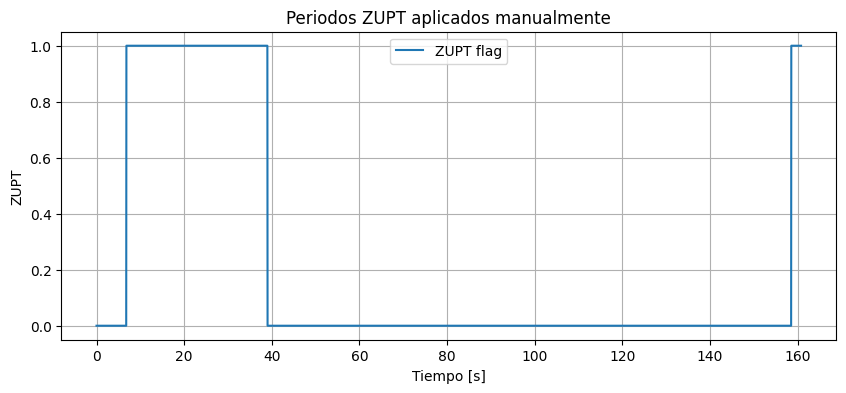

In [124]:
plt.figure(figsize=(10, 4))
plt.plot(df_ins["t"], df_ins["zupt_flag"], label="ZUPT flag")
plt.xlabel("Tiempo [s]")
plt.ylabel("ZUPT")
plt.title("Periodos ZUPT aplicados manualmente")
plt.grid(True)
plt.legend()
plt.show()

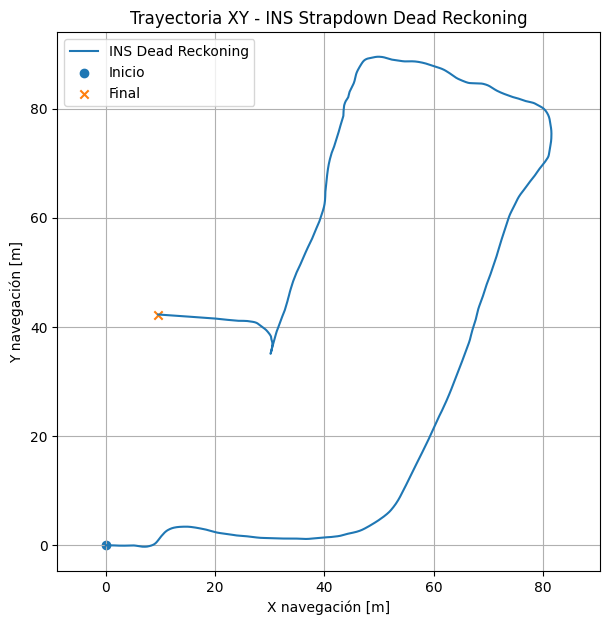

In [125]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.plot(df_ins["px"], df_ins["py"], label="INS Dead Reckoning")

plt.scatter(df_ins["px"].iloc[0], df_ins["py"].iloc[0], label="Inicio", marker="o")
plt.scatter(df_ins["px"].iloc[-1], df_ins["py"].iloc[-1], label="Final", marker="x")

plt.xlabel("X navegación [m]")
plt.ylabel("Y navegación [m]")
plt.title("Trayectoria XY - INS Strapdown Dead Reckoning")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

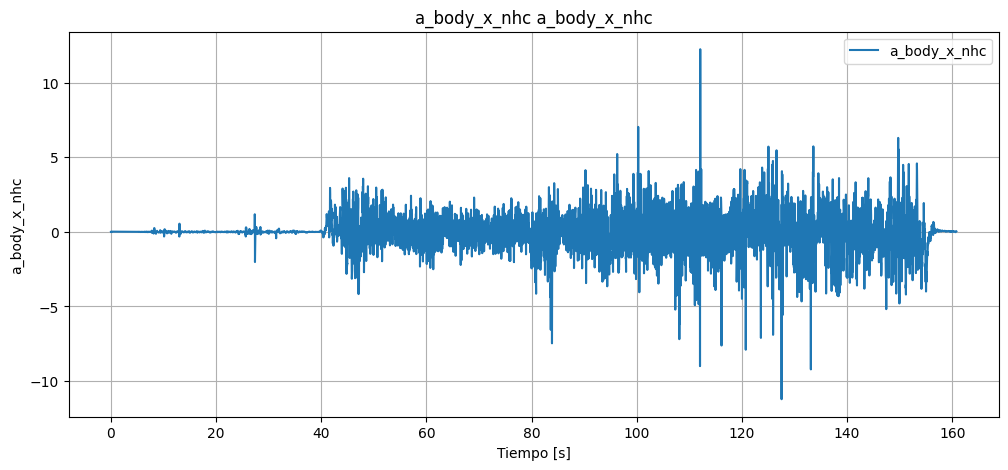

In [126]:
# for col in ["a_body_x_nhc", "a_body_y_nhc", "a_body_z_nhc"]:
col = "a_body_x_nhc"
plt.figure(figsize=(12, 5))
plt.plot(df_ins["t"], df_ins[col], label=col)
plt.xlabel("Tiempo [s]")
plt.ylabel("a_body_x_nhc")
plt.title(f"a_body_x_nhc {col}")
plt.legend()
plt.grid(True)
plt.show()

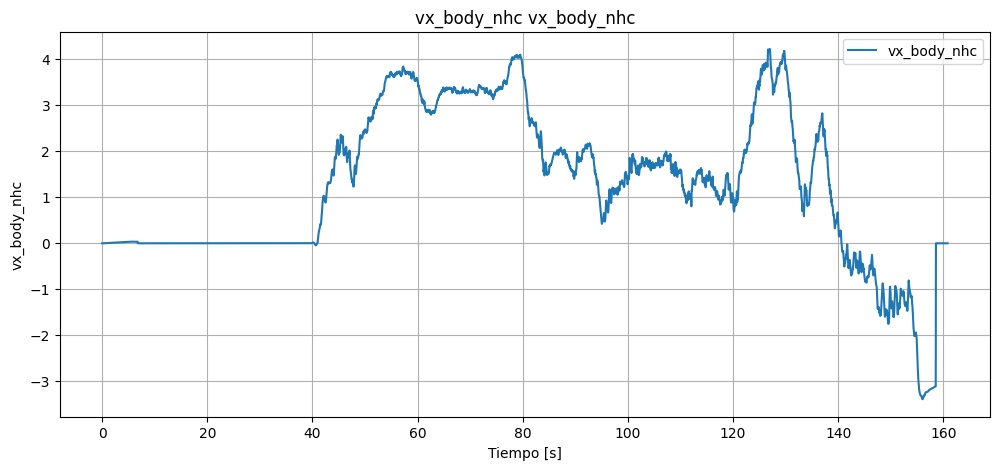

In [127]:
# for col in ["vx_body_nhc", "vy_body_nhc", "vz_body_nhc"]:
col = "vx_body_nhc"
plt.figure(figsize=(12, 5))
plt.plot(df_ins["t"], df_ins[col], label=col)
plt.xlabel("Tiempo [s]")
plt.ylabel("vx_body_nhc")
plt.title(f"vx_body_nhc {col}")
plt.legend()
plt.grid(True)
plt.show()


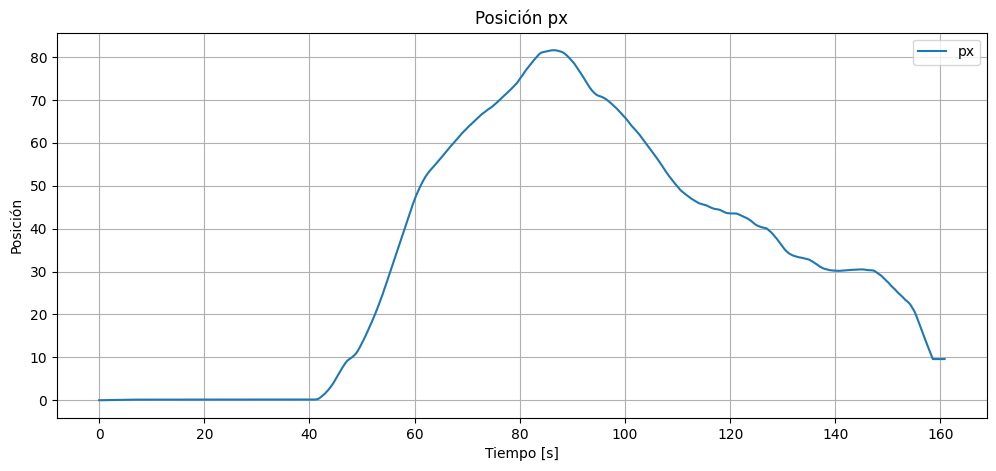

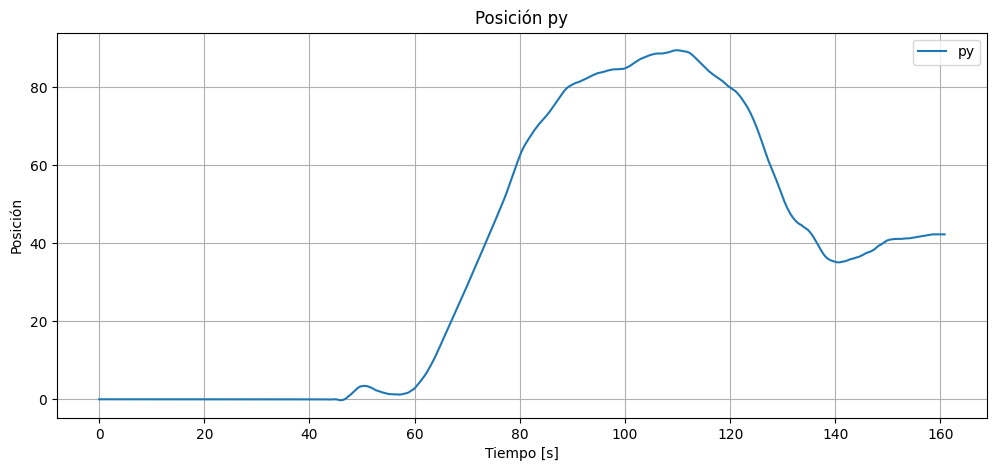

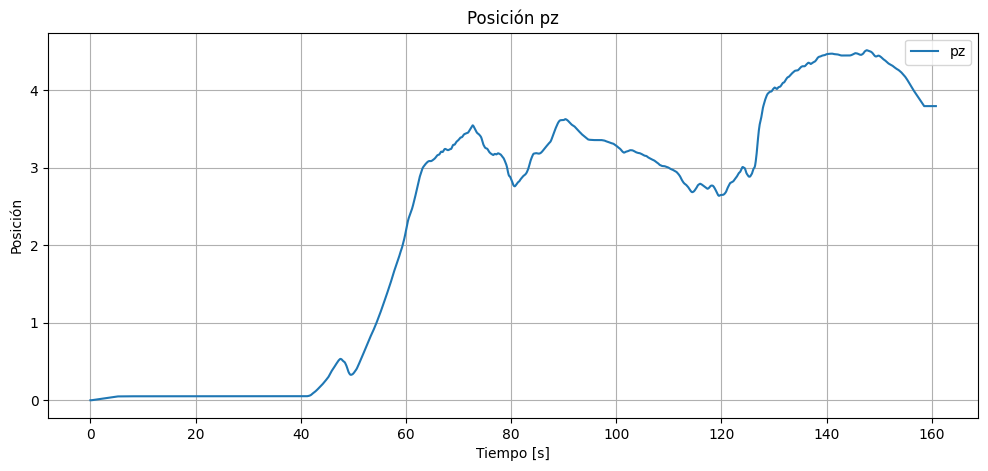

In [128]:
for col in ["px", "py", "pz"]:
    plt.figure(figsize=(12, 5))
    plt.plot(df_ins["t"], df_ins[col], label=col)
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Posición")
    plt.title(f"Posición {col}")
    plt.legend()
    plt.grid(True)
    plt.show()